10000


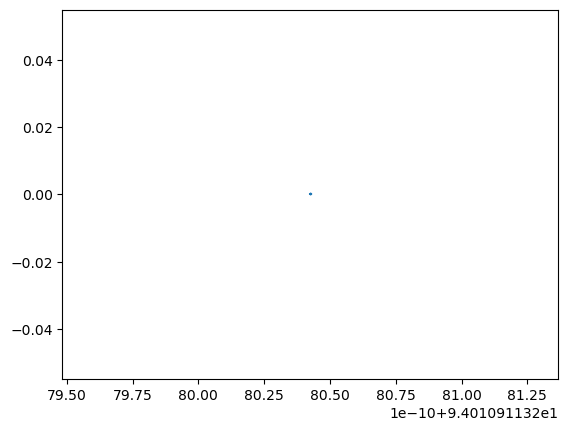

In [12]:
import astropy
import numpy as np
from pathlib import Path
from astropy.nddata import CCDData
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import warnings
import glob


mass_star = 1.21
r_star = 1.357
teff_star = 6163
nu_max_sun_uHz = 3090.0
teff_sun_K = 5777.0
max_rms_amplitude_sun = 2.1
delta_nu_sun = 135.1
epsilon = 1.55
    
def calc_maximum_rms_amplitude_radial(mass_star, teff_star):
    luminosity_ratio = (r_star**2) * (teff_star / teff_sun_K) ** 4
    power = -0.093
    t_red_star = 8907*(luminosity_ratio**power)
    delta_t = 1250
    dwarf_suppression_beta = 1 - np.exp((teff_star - t_red_star)/(delta_t))

    max_rms_amplitude_star = max_rms_amplitude_sun * dwarf_suppression_beta * luminosity_ratio *(mass_star**-1) * ((teff_star / teff_sun_K) ** (-2))   
    
    return max_rms_amplitude_star


l = np.linspace(0,3,4)
n = np.linspace(0,30,31)
V = [1, 1.505, 0.620, 0.075]

    
def calc_nl_rms_amplitude_radial(mass_star, teff_star, n, l):
    
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    #print(nu_max)
    delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))
    
    #nu_nl.append(delta_nu * (n + (l/2) + epsilon))
    
    nu_nl = delta_nu * (n + (l/2) + epsilon)
    
    envelope_FWHM = 0.66 * (nu_max ** 0.88)
    
    if teff_star > teff_sun_K:
        envelope_FWHM = envelope_FWHM * (1+6e-4 * (teff_star - teff_sun_K))
                
    width_envelope = envelope_FWHM / (2 * np.sqrt(2*np.log(2)))
        
    nl_rms_ampliude_star = (((calc_maximum_rms_amplitude_radial(mass_star, teff_star) ** 2) * np.exp(-((nu_nl - nu_max)**2)/(2*(width_envelope**2))))**0.5)
    
    return nl_rms_ampliude_star


def width_parameter(mass_star, teff_star, a, b):
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    P = (a*(nu_max/3090)) + b
    return P

alpha = width_parameter(mass_star, teff_star, 2.95, 0.39)
width_alpha = width_parameter(mass_star, teff_star, 3.08, 3.32)
delta_width_dip = width_parameter(mass_star, teff_star, -0.47, 0.62)
W_dip = width_parameter(mass_star, teff_star, 4637, -141)
nu_dip = width_parameter(mass_star, teff_star, 2984, 60)

def calc_width_nl(mass_star, teff_star, n, l):
    
    nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
    delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))
    nu_nl = delta_nu * (n + (l/2) + epsilon)
    
    Lnwidth = ((alpha * np.log(nu_nl/nu_max)) + np.log(width_alpha)) + (np.log(delta_width_dip)/(1 + (((2 * np.log(nu_nl/nu_dip))/(np.log(W_dip/nu_max)))**2)))
    width_nl = np.exp(Lnwidth)

    return width_nl

def lorentz(freq, centroid, FWHM): 
    #scale parameter is the half-width-half-maximum value of the Lorentz curve
    return ((FWHM/2)**2 / ((freq - centroid)**2 + (FWHM/2)**2))

def calc_power_amplitude(amp,width):
    return (2/np.pi)*((amp**2)/width)



nu_max = nu_max_sun_uHz * (mass_star / (r_star**2)) * (teff_star / teff_sun_K) ** (-0.5)
envelope_FWHM = 0.66 * (nu_max ** 0.88)
delta_nu = delta_nu_sun * (mass_star**0.5) * (r_star**(-1.5))

if teff_star > teff_sun_K:
        envelope_FWHM = envelope_FWHM * (1+6e-4 * (teff_star - teff_sun_K))
#print(envelope_FWHM)

standev_envelope = envelope_FWHM / (2*np.sqrt(2*np.log(2)))
nu_envelope_min = nu_max - (3*standev_envelope)
nu_envelope_max = nu_max + (3*standev_envelope)

n_min = []
n_max = []

for i in l:
    n_min.append(int((nu_envelope_min/delta_nu) - ((i/2) + epsilon)))
    n_max.append(int((nu_envelope_max/delta_nu) - ((i/2) + epsilon)))

nu_modes = {0: [], 1: [], 2: [], 3: []}

for j in l:
    #power_density = np.zeros(len(nu_range))
    
    for i in np.linspace(min(n_min), max(n_max), (max(n_max)-min(n_min))+1):
        nu_nl = delta_nu * (i + (j/2) + epsilon)
        nu_modes[int(j)].append(nu_nl)

nu_range = np.linspace(1000,3000,10000)
#power_density = np.zeros(len(nu_range))
power_density = np.zeros(len(nu_range))

for j in l:
    #power_density = np.zeros(len(nu_range))
    
    for i in np.linspace(min(n_min), max(n_max), (max(n_max)-min(n_min))+1):
        nu_nl = delta_nu * (i + (j/2) + epsilon)
        #nu_modes[int(j)].append(nu_nl)
        amplitude_nl =V[int(j)] * calc_nl_rms_amplitude_radial(mass_star, teff_star, i, j)
        width_nl = calc_width_nl(mass_star, teff_star, i, j)
        power_amplitude = calc_power_amplitude(amplitude_nl, width_nl)
        power_density +=(power_amplitude * lorentz(nu_range, nu_nl, width_nl))

    for list in nu_modes:
        nu_modes[list] = np.array(nu_modes[list])

 
#plt.plot(nu_range, power_density)
print(len(power_density))

def large_seperation(freq):
    return np.diff(freq)

def small_freq_seperation_02(nu_l0, nu_l2):
    min_len = min(len(nu_l0), len(nu_l2))
    return nu_l0[1:min_len] - nu_l2[:min_len-1]

delta_nu_numerical = large_seperation(nu_modes[0])
delta_nu_02 = small_freq_seperation_02(nu_modes[0], nu_modes[2])

plt.plot(delta_nu_numerical, delta_nu_02)
        
    
